# VersaBank Dynamic Holdback Model
### Credit Risk Analytics — Lending Partner Portfolio

---

This notebook builds an end-to-end holdback framework for a multi-partner loan portfolio. It covers:

1. **Data Preprocessing** — cleaning, feature engineering, encoding, scaling
2. **Model Training** — logistic regression (sklearn + statsmodels)
3. **Validation & Visualizations** — ROC curve, coefficient plot, PD distribution
4. **Holdback Calculation** — EL = PD × EAD × LGD + variance buffer
5. **Vintage / Cohort Analysis** — 10-year default rate trends by origination year

**Dataset:** `Loan_default.csv` — 255,347 loan records, 18 features, binary default target  
**Model:** Logistic Regression | **Validation metric:** ROC-AUC (threshold: 0.70)

---
## Imports & Global Settings

In [1]:
import pandas as pd
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
import statsmodels.api as sm

# ── Global config ─────────────────────────────────────────────────────────────
RANDOM_SEED  = 42
LGD          = 0.50        # Loss Given Default assumption (50% recovery rate)
DATA_PATH    = 'C:/Users/oblok/Downloads/Loan_default.csv'
OUT_DIR      = 'C:/Users/oblok/Documents/versabank_holdback/'

np.random.seed(RANDOM_SEED)

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

print('All imports successful.')

All imports successful.


---
## Step 1 — Data Preprocessing

We load the raw loan data and prepare it for modelling. This includes:
- Engineering a **Lender Partner** column (simulated, 5 partners with weighted volume)
- Engineering **Origination Dates** spanning 2015–2024 for vintage analysis
- Encoding binary Yes/No columns as 0/1
- **Winsorizing** continuous features at the 1st/99th percentile to remove outliers
- **One-hot encoding** categorical features
- **Standardizing** continuous features (mean=0, std=1)

In [2]:
# ── Load raw data ─────────────────────────────────────────────────────────────
print('Loading raw data...')
df_raw = pd.read_csv(DATA_PATH)
print(f'  Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns')
print(f'  Missing values: {df_raw.isnull().sum().sum()}')
print(f'  Default rate: {df_raw["Default"].mean():.2%}')
df_raw.head(3)

Loading raw data...


  Shape: 255,347 rows x 18 columns
  Missing values: 0
  Default rate: 11.61%


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1


In [3]:
df = df_raw.copy()

# ── Engineer: Lender Partner ──────────────────────────────────────────────────
partners = ['Partner A', 'Partner B', 'Partner C', 'Partner D', 'Partner E']
weights  = [0.30, 0.25, 0.20, 0.15, 0.10]
df['Lender_Partner'] = np.random.choice(partners, size=len(df), p=weights)

# ── Engineer: Origination Date (10-year history) ──────────────────────────────
random_months = np.random.randint(0, 120, size=len(df))
base_date = pd.Timestamp('2015-01-01')
df['Origination_Date']      = base_date + pd.to_timedelta(random_months * 30, unit='D')
df['Origination_Year']       = df['Origination_Date'].dt.year
df['Origination_YearMonth']  = df['Origination_Date'].dt.to_period('M').astype(str)

# ── Drop identifier ───────────────────────────────────────────────────────────
df.drop(columns=['LoanID'], inplace=True)

# ── Encode binary Yes/No -> 0/1 ───────────────────────────────────────────────
for col in ['HasMortgage', 'HasDependents', 'HasCoSigner']:
    df[col] = (df[col] == 'Yes').astype(int)

# ── Winsorize at 1st / 99th percentile ────────────────────────────────────────
continuous_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore',
                   'MonthsEmployed', 'InterestRate', 'DTIRatio']
for col in continuous_cols:
    df[col] = df[col].clip(df[col].quantile(0.01), df[col].quantile(0.99))

# ── One-hot encode categoricals ───────────────────────────────────────────────
df = pd.get_dummies(df, columns=['Education', 'EmploymentType', 'MaritalStatus',
                                  'LoanPurpose', 'Lender_Partner'], drop_first=True)

# ── Standardize continuous features ──────────────────────────────────────────
scaler = StandardScaler()
df[continuous_cols] = scaler.fit_transform(df[continuous_cols])

print(f'Preprocessing complete. Final shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Preprocessing complete. Final shape: 255,347 rows x 32 columns
Columns: ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'HasMortgage', 'HasDependents', 'HasCoSigner', 'Default', 'Origination_Date', 'Origination_Year', 'Origination_YearMonth', 'Education_High School', "Education_Master's", 'Education_PhD', 'EmploymentType_Part-time', 'EmploymentType_Self-employed', 'EmploymentType_Unemployed', 'MaritalStatus_Married', 'MaritalStatus_Single', 'LoanPurpose_Business', 'LoanPurpose_Education', 'LoanPurpose_Home', 'LoanPurpose_Other', 'Lender_Partner_Partner B', 'Lender_Partner_Partner C', 'Lender_Partner_Partner D', 'Lender_Partner_Partner E']


---
## Step 2 — Model Training

We fit two models:
- **sklearn LogisticRegression** — fast scoring, produces `predict_proba()` PD scores for all loans
- **statsmodels Logit** — produces the regulatory-grade coefficient table with p-values and confidence intervals

We use `class_weight='balanced'` to correct for the 88/12 class imbalance in the target variable.

In [4]:
# ── Train-test split (stratified) ─────────────────────────────────────────────
drop_cols = ['Default', 'Origination_Date', 'Origination_Year', 'Origination_YearMonth']
X = df.drop(columns=drop_cols)
y = df['Default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED, stratify=y
)

print(f'Train: {X_train.shape[0]:,} loans | Test: {X_test.shape[0]:,} loans')
print(f'Train default rate: {y_train.mean():.4f} | Test default rate: {y_test.mean():.4f}')

Train: 204,277 loans | Test: 51,070 loans
Train default rate: 0.1161 | Test default rate: 0.1161


In [5]:
# ── sklearn LogisticRegression ────────────────────────────────────────────────
sk_model = LogisticRegression(
    class_weight='balanced', max_iter=1000,
    random_state=RANDOM_SEED, solver='lbfgs'
)
sk_model.fit(X_train, y_train)

y_prob_test = sk_model.predict_proba(X_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_prob_test)

print(f'ROC-AUC (test set): {roc_auc:.4f}')
print('PASS' if roc_auc >= 0.70 else 'WARNING: below 0.70 threshold')

# Score full portfolio
df['PD'] = sk_model.predict_proba(X)[:, 1]

ROC-AUC (test set): 0.7531
PASS


In [6]:
# ── statsmodels Logit — regulatory coefficient table ─────────────────────────
print('Fitting statsmodels Logit (may take ~60s)...')
X_train_sm = sm.add_constant(X_train.astype(float))
sm_result  = sm.Logit(y_train.astype(float), X_train_sm).fit(
    method='lbfgs', maxiter=1000, disp=False
)
print(sm_result.summary2())

Fitting statsmodels Logit (may take ~60s)...


                               Results: Logit
Model:                   Logit               Method:              MLE        
Dependent Variable:      Default             Pseudo R-squared:    0.119      
Date:                    2026-05-28 14:02    AIC:                 129295.7302
No. Observations:        204277              BIC:                 129592.3200
Df Model:                28                  Log-Likelihood:      -64619.    
Df Residuals:            204248              LL-Null:             -73363.    
Converged:               1.0000              LLR p-value:         0.0000     
No. Iterations:          186.0000            Scale:               1.0000     
-----------------------------------------------------------------------------
                              Coef.  Std.Err.    z     P>|z|   [0.025  0.975]
-----------------------------------------------------------------------------
const                        -2.3433   0.0388 -60.3564 0.0000 -2.4194 -2.2672
Age               

---
## Step 3 — Validation & Visualizations

Four charts:
1. **ROC Curve** — model discrimination power vs. random baseline
2. **Default Rate by Lender Partner** — portfolio segmentation
3. **Coefficient Plot** — which features drive default risk (and in which direction)
4. **PD Score Distribution** — visual separation between defaulters and non-defaulters

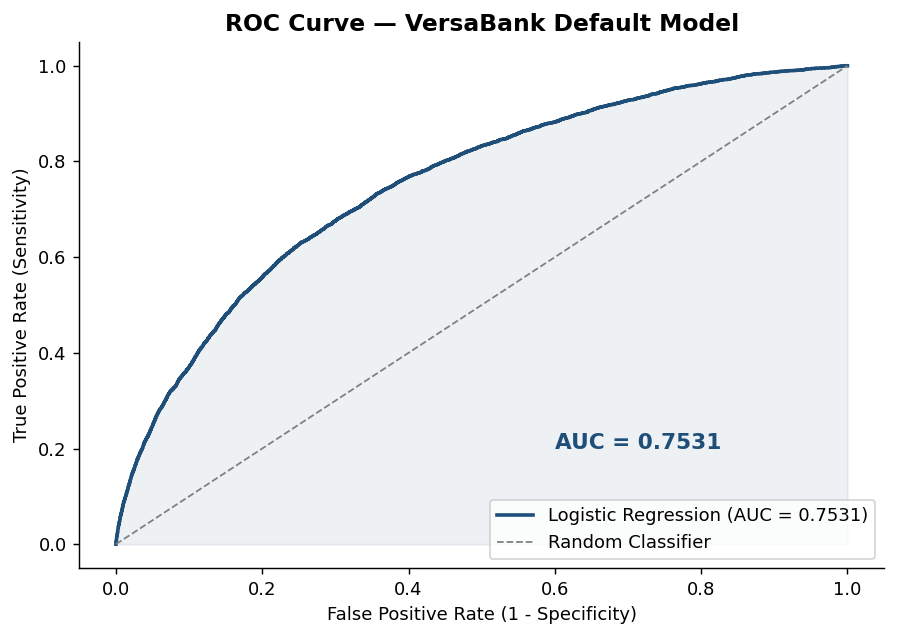

In [7]:
# ── Chart 1: ROC Curve ────────────────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test, y_prob_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color='#1f4e79', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.4f})')
ax.plot([0,1],[0,1], color='grey', lw=1, linestyle='--', label='Random Classifier')
ax.fill_between(fpr, tpr, alpha=0.08, color='#1f4e79')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('ROC Curve — VersaBank Default Model')
ax.annotate(f'AUC = {roc_auc:.4f}', xy=(0.6, 0.2), fontsize=12,
            color='#1f4e79', fontweight='bold')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_01_roc_curve.png')
plt.show()

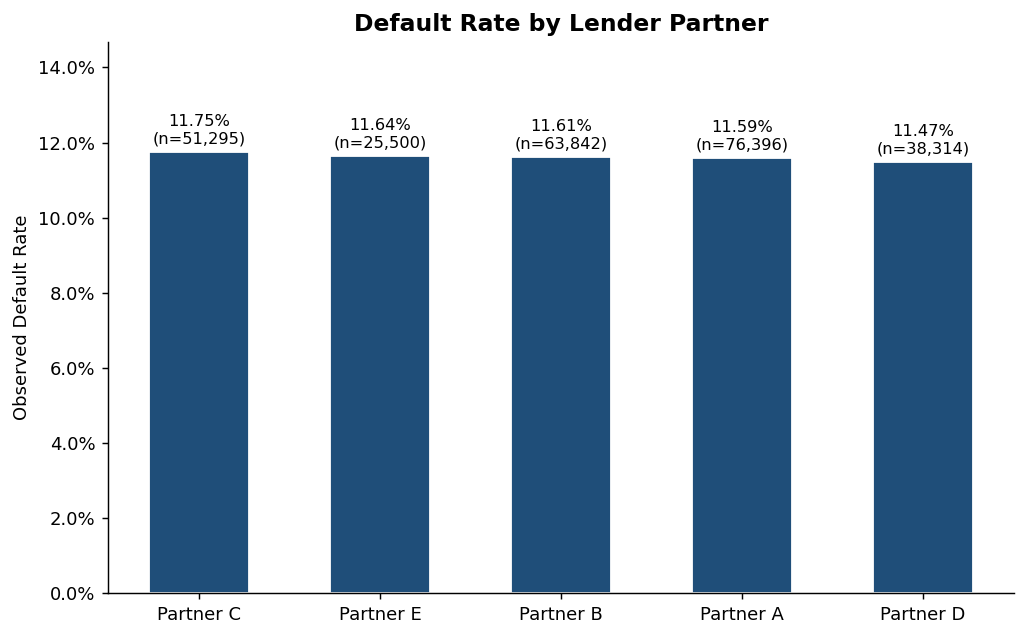

In [8]:
# ── Reconstruct partner labels ────────────────────────────────────────────────
partner_cols = [c for c in df.columns if c.startswith('Lender_Partner_')]

def get_partner(row):
    for col in partner_cols:
        if row[col] == 1:
            return col.replace('Lender_Partner_', '')
    return 'Partner A'

df['Partner'] = df.apply(get_partner, axis=1)

# ── Chart 2: Default Rate by Lender Partner ───────────────────────────────────
partner_stats = (
    df.groupby('Partner')['Default']
    .agg(['mean','count'])
    .rename(columns={'mean':'Default_Rate','count':'Loan_Count'})
    .sort_values('Default_Rate', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(partner_stats['Partner'], partner_stats['Default_Rate']*100,
              color='#1f4e79', edgecolor='white', width=0.55)
for bar, (_, row) in zip(bars, partner_stats.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f"{row['Default_Rate']*100:.2f}%\n(n={row['Loan_Count']:,})",
            ha='center', va='bottom', fontsize=9)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel('Observed Default Rate')
ax.set_title('Default Rate by Lender Partner')
ax.set_ylim(0, partner_stats['Default_Rate'].max()*100*1.25)
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_02_default_by_partner.png')
plt.show()

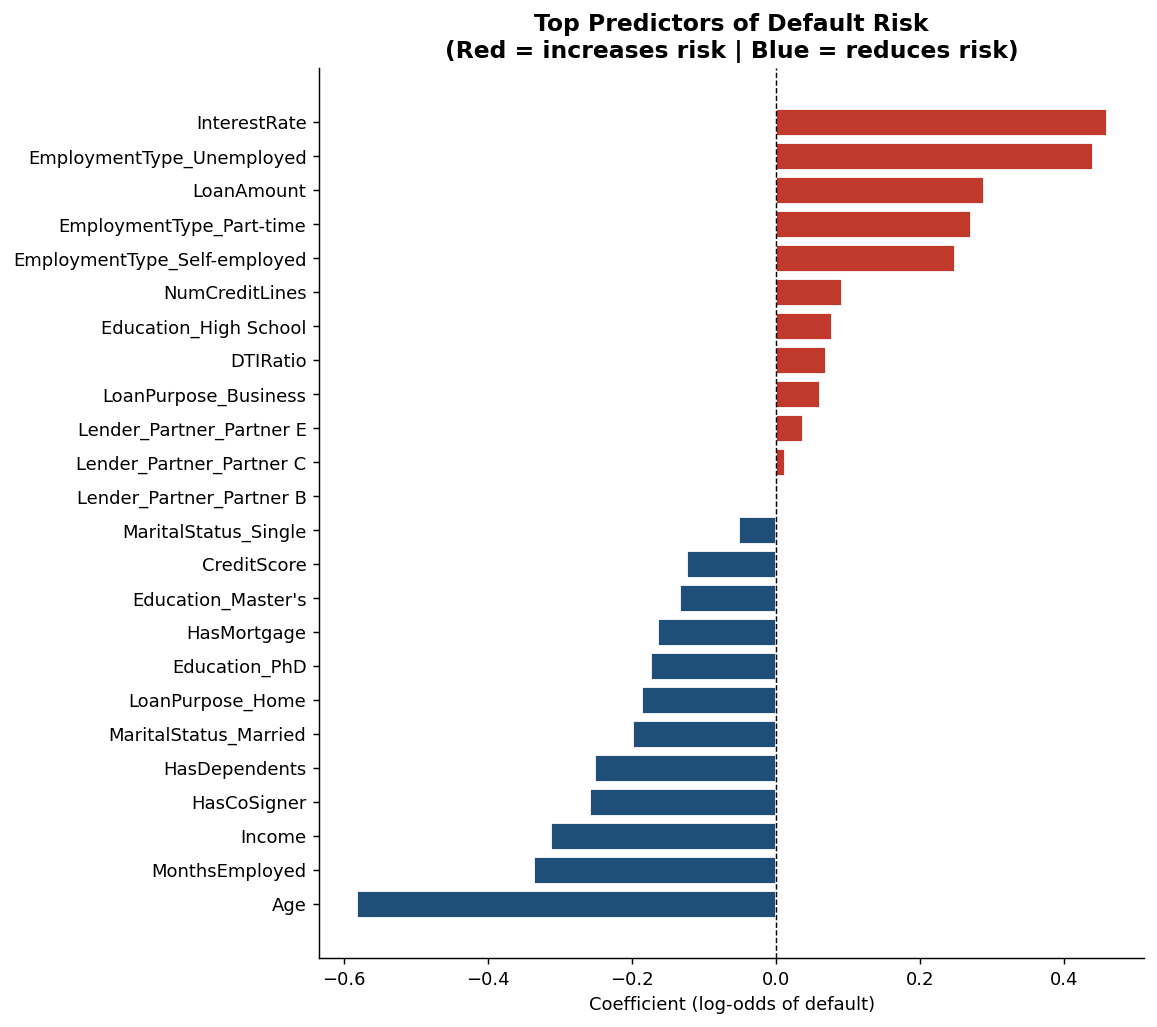

In [9]:
# ── Chart 3: Coefficient Plot ─────────────────────────────────────────────────
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': sk_model.coef_[0]
}).sort_values('Coefficient')

top_n = 12
coef_plot = pd.concat([coef_df.head(top_n), coef_df.tail(top_n)])
colors = ['#c0392b' if c > 0 else '#1f4e79' for c in coef_plot['Coefficient']]

fig, ax = plt.subplots(figsize=(9, 8))
ax.barh(coef_plot['Feature'], coef_plot['Coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8, linestyle='--')
ax.set_xlabel('Coefficient (log-odds of default)')
ax.set_title('Top Predictors of Default Risk\n(Red = increases risk | Blue = reduces risk)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_03_coefficients.png')
plt.show()

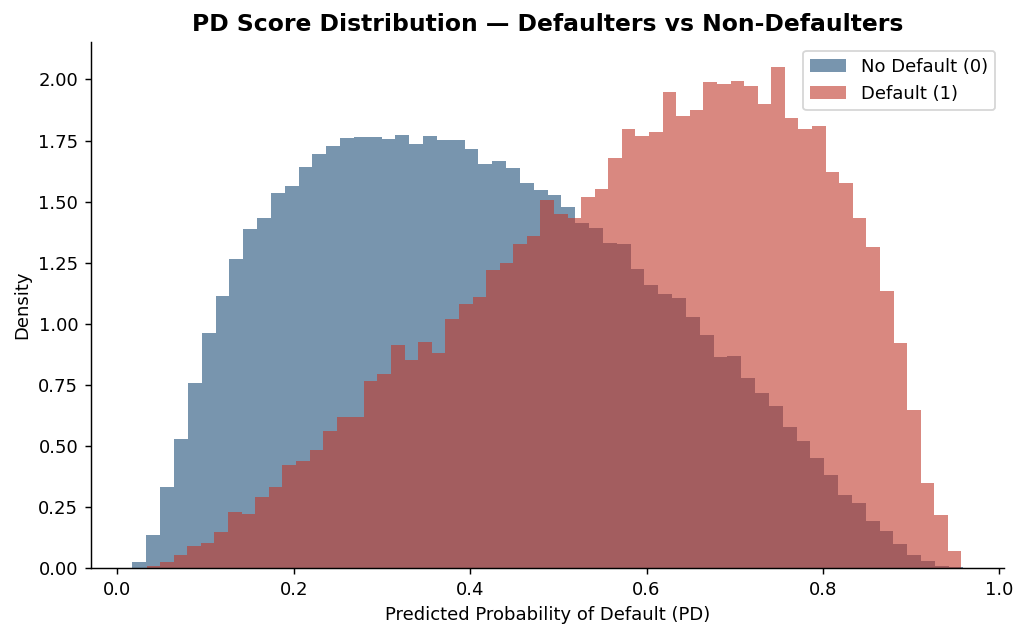

In [10]:
# ── Chart 4: PD Score Distribution ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df[df['Default']==0]['PD'], bins=60, alpha=0.6,
        color='#1f4e79', label='No Default (0)', density=True)
ax.hist(df[df['Default']==1]['PD'], bins=60, alpha=0.6,
        color='#c0392b', label='Default (1)', density=True)
ax.set_xlabel('Predicted Probability of Default (PD)')
ax.set_ylabel('Density')
ax.set_title('PD Score Distribution — Defaulters vs Non-Defaulters')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_04_pd_distribution.png')
plt.show()

---
## Step 4 — Holdback Calculation

We translate PD scores into a **recommended holdback percentage** per lending partner.

**Formula:**
$$EL = PD \times EAD \times LGD$$

Where:
- **PD** = Probability of Default (from logistic regression)
- **EAD** = Exposure at Default (original loan amount in dollars)
- **LGD** = Loss Given Default (assumed 50% — standard Basel II floor)

The **variance buffer** = 1 portfolio-level standard deviation of loan-level EL per partner, covering unexpected macroeconomic loss spikes.

$$\text{Holdback \%} = \frac{\sum EL + \text{Variance Buffer}}{\text{Total EAD}}$$

In [11]:
# Recover original (un-standardized) loan amounts for EAD
df['EAD'] = pd.read_csv(DATA_PATH)['LoanAmount'].values

# Expected Loss per loan
df['EL'] = df['PD'] * df['EAD'] * LGD

print(f'Portfolio Expected Loss: ${df["EL"].sum():,.0f}')
print(f'As % of total EAD:       {df["EL"].sum() / df["EAD"].sum() * 100:.2f}%')

Portfolio Expected Loss: $7,534,828,260
As % of total EAD:       23.13%


In [12]:
# ── Aggregate holdback by partner ──────────────────────────────────────────────
results = []
for partner, group in df.groupby('Partner'):
    total_ead        = group['EAD'].sum()
    total_el         = group['EL'].sum()
    variance_buffer  = group['EL'].std() * np.sqrt(len(group))
    total_req        = total_el + variance_buffer
    results.append({
        'Partner'         : partner,
        'Loan_Count'      : len(group),
        'Total_EAD'       : total_ead,
        'Expected_Loss'   : total_el,
        'EL_Pct'          : total_el / total_ead * 100,
        'Variance_Buffer' : variance_buffer,
        'Buffer_Pct'      : variance_buffer / total_ead * 100,
        'Holdback_Pct'    : total_req / total_ead * 100,
    })

holdback_df = pd.DataFrame(results).sort_values('Holdback_Pct', ascending=False)
holdback_df[['Partner','Loan_Count','Total_EAD','EL_Pct','Buffer_Pct','Holdback_Pct']].style.format({
    'Total_EAD'  : '${:,.0f}',
    'EL_Pct'     : '{:.2f}%',
    'Buffer_Pct' : '{:.2f}%',
    'Holdback_Pct': '{:.2f}%'
})

,Partner,Loan_Count,Total_EAD,EL_Pct,Buffer_Pct,Holdback_Pct
4,Partner E,25500,"$3,250,209,708",23.42%,0.12%,23.54%
2,Partner C,51295,"$6,529,289,875",23.19%,0.08%,23.27%
1,Partner B,63842,"$8,170,720,104",23.13%,0.07%,23.21%
0,Partner A,76396,"$9,765,482,812",23.10%,0.07%,23.16%
3,Partner D,38314,"$4,861,178,073",22.91%,0.10%,23.01%


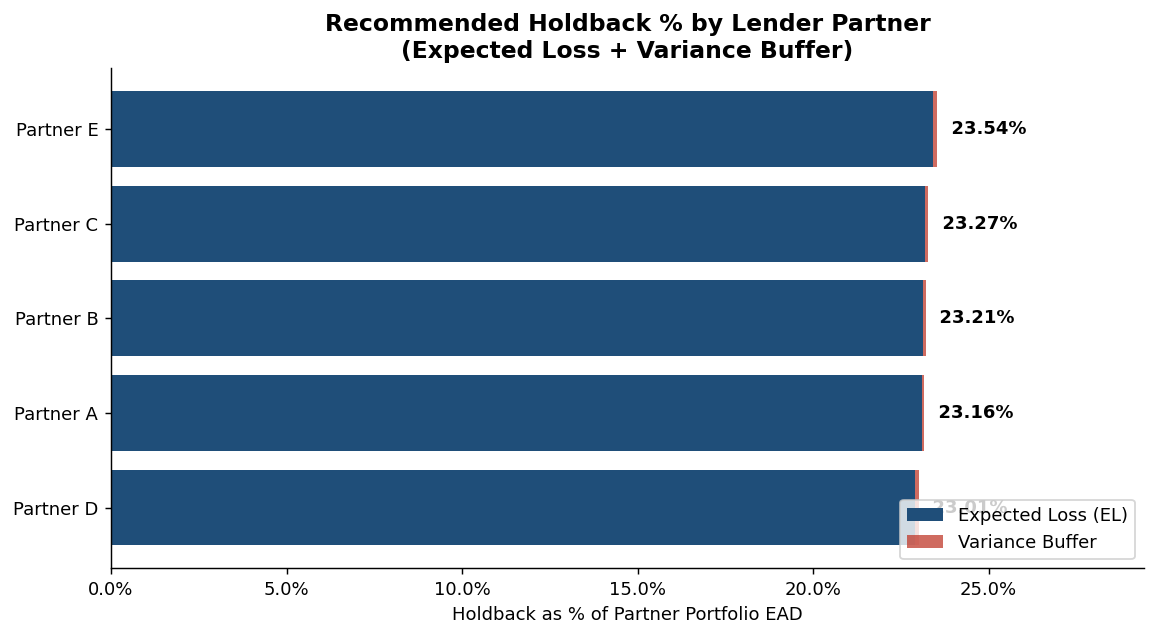

In [13]:
# ── Chart 5: Holdback % by Partner (stacked) ──────────────────────────────────
hdf = holdback_df.sort_values('Holdback_Pct', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(hdf['Partner'], hdf['EL_Pct'],    color='#1f4e79', label='Expected Loss (EL)')
ax.barh(hdf['Partner'], hdf['Buffer_Pct'],left=hdf['EL_Pct'],
        color='#c0392b', alpha=0.75, label='Variance Buffer')
for _, row in hdf.iterrows():
    ax.text(row['Holdback_Pct'] + 0.05, row['Partner'],
            f"  {row['Holdback_Pct']:.2f}%", va='center',
            fontsize=10, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Holdback as % of Partner Portfolio EAD')
ax.set_title('Recommended Holdback % by Lender Partner\n(Expected Loss + Variance Buffer)')
ax.legend(loc='lower right')
ax.set_xlim(0, hdf['Holdback_Pct'].max() * 1.25)
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_05_holdback.png')
plt.show()

---
## Step 5 — Vintage / Cohort Analysis

We group loans by origination year (vintage) and analyze how default rates evolve across cohorts.
This maps directly to the requirement for **"time-series and vintage/cohort analyses"** in the role.

Three charts:
- **Chart 6:** Default rate by vintage year (actual vs. model PD)
- **Chart 7:** Cumulative default curves by vintage (classic seasoning curves)
- **Chart 8:** Heatmap — vintage year × lending partner

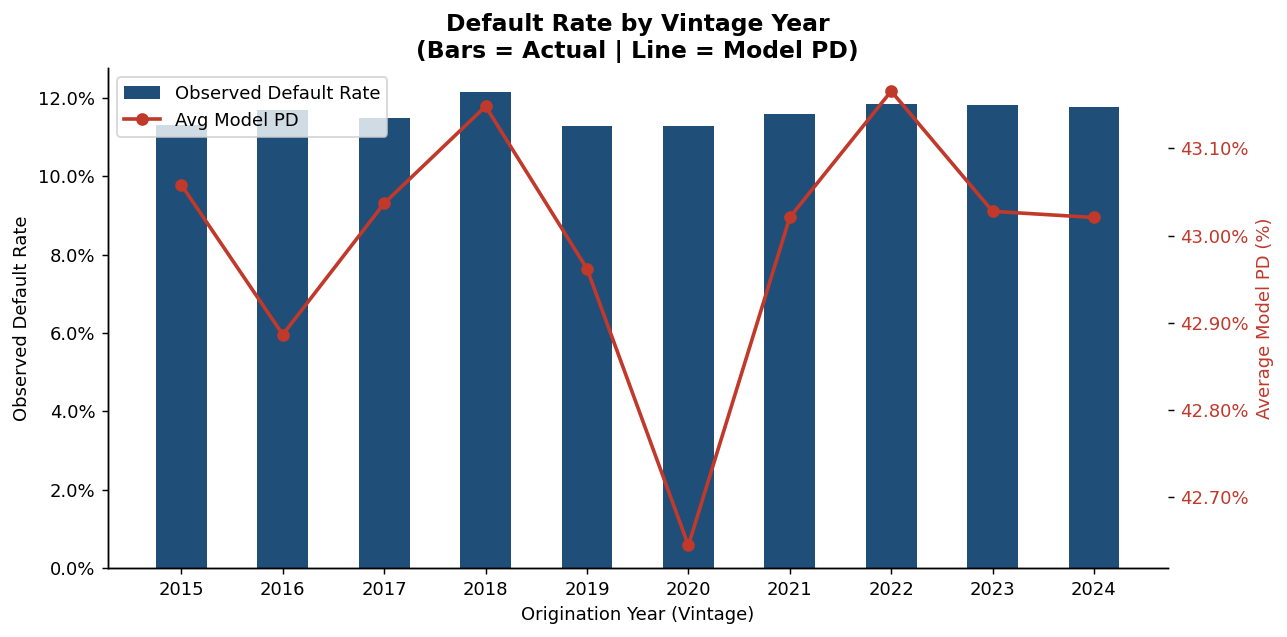

In [14]:
df['Origination_Date'] = pd.to_datetime(df['Origination_Date'])
df['Vintage_Year']     = df['Origination_Date'].dt.year

vintage_stats = (
    df.groupby('Vintage_Year')
    .agg(Default_Rate=('Default','mean'), Loan_Count=('Default','count'), Avg_PD=('PD','mean'))
    .reset_index()
)

# ── Chart 6: Default Rate by Vintage Year ─────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(vintage_stats['Vintage_Year'], vintage_stats['Default_Rate']*100,
        color='#1f4e79', width=0.5, label='Observed Default Rate')
ax2 = ax1.twinx()
ax2.plot(vintage_stats['Vintage_Year'], vintage_stats['Avg_PD']*100,
         color='#c0392b', marker='o', lw=2, ms=6, label='Avg Model PD')
ax2.set_ylabel('Average Model PD (%)', color='#c0392b')
ax2.tick_params(axis='y', labelcolor='#c0392b')
ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
ax1.set_xlabel('Origination Year (Vintage)')
ax1.set_ylabel('Observed Default Rate')
ax1.set_title('Default Rate by Vintage Year\n(Bars = Actual | Line = Model PD)')
ax1.set_xticks(vintage_stats['Vintage_Year'])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_06_vintage_default_rate.png')
plt.show()

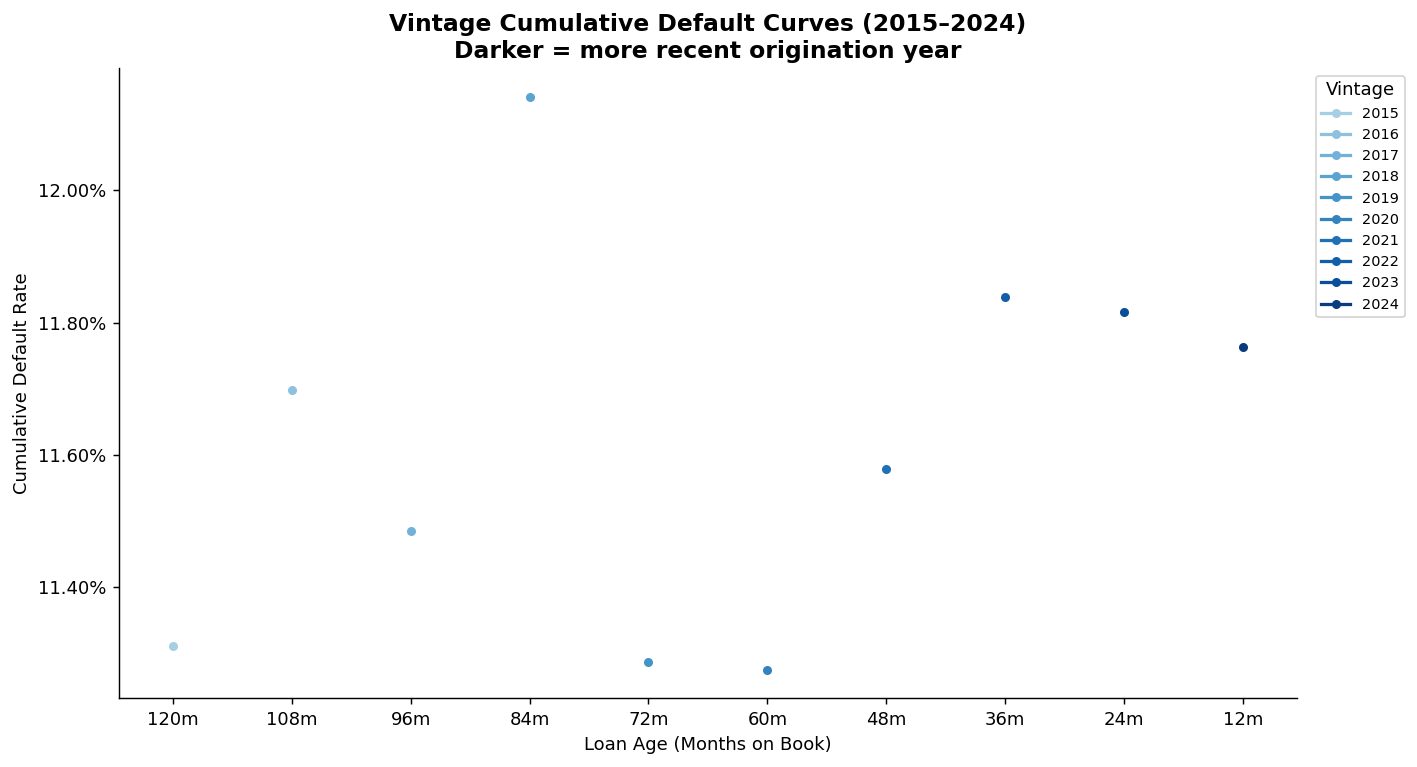

In [15]:
# ── Chart 7: Cumulative Vintage Curves ────────────────────────────────────────
OBSERVATION_DATE = pd.Timestamp('2025-01-01')
df['Months_On_Book'] = (
    (OBSERVATION_DATE.year  - df['Origination_Date'].dt.year)  * 12 +
    (OBSERVATION_DATE.month - df['Origination_Date'].dt.month)
).clip(lower=1)

df['Age_Band'] = pd.cut(df['Months_On_Book'],
    bins=[0,12,24,36,48,60,72,84,96,108,120],
    labels=['12m','24m','36m','48m','60m','72m','84m','96m','108m','120m'])

fig, ax = plt.subplots(figsize=(11, 6))
colors  = plt.cm.Blues(np.linspace(0.35, 0.95, len(vintage_stats)))

for color, (vintage, group) in zip(colors, df.groupby('Vintage_Year')):
    age_df = (
        group.groupby('Age_Band', observed=True)['Default']
        .agg(['sum','count'])
        .rename(columns={'sum':'Defaults','count':'Loans'})
        .sort_values('Age_Band')
    )
    age_df['Cum_Default_Rate'] = age_df['Defaults'].cumsum() / age_df['Loans'].iloc[0] * 100
    ax.plot(age_df.index.astype(str), age_df['Cum_Default_Rate'],
            marker='o', ms=4, lw=1.8, color=color, label=str(vintage))

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlabel('Loan Age (Months on Book)')
ax.set_ylabel('Cumulative Default Rate')
ax.set_title('Vintage Cumulative Default Curves (2015–2024)\nDarker = more recent origination year')
ax.legend(title='Vintage', bbox_to_anchor=(1.01,1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_07_vintage_curves.png')
plt.show()

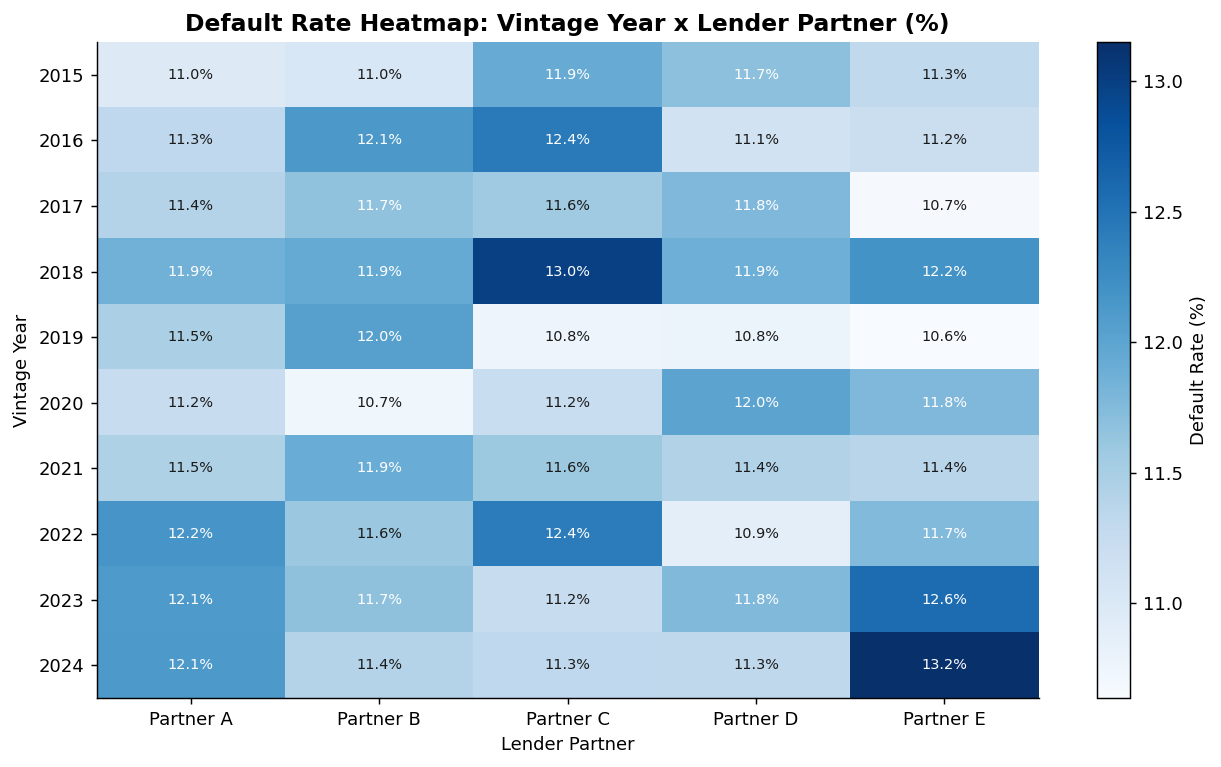

In [16]:
# ── Chart 8: Heatmap — Vintage x Partner ─────────────────────────────────────
pivot = (
    df.groupby(['Vintage_Year','Partner'])['Default']
    .mean().unstack('Partner') * 100
)

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel('Lender Partner')
ax.set_ylabel('Vintage Year')
ax.set_title('Default Rate Heatmap: Vintage Year x Lender Partner (%)')
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=8, color='white' if val > pivot.values.mean() else '#1a1a1a')
plt.colorbar(im, ax=ax, label='Default Rate (%)')
plt.tight_layout()
plt.savefig(OUT_DIR + 'chart_08_heatmap.png')
plt.show()

---
## Final Output — Holdback Recommendation Table

In [17]:
print('=' * 65)
print('VERSABANK — RECOMMENDED HOLDBACK BY LENDING PARTNER')
print('=' * 65)
for _, row in holdback_df.iterrows():
    print(f"\n  {row['Partner']}")
    print(f"    Loans             : {row['Loan_Count']:,}")
    print(f"    Total EAD         : ${row['Total_EAD']:,.0f}")
    print(f"    Expected Loss     : {row['EL_Pct']:.2f}% of EAD")
    print(f"    Variance Buffer   : {row['Buffer_Pct']:.2f}% of EAD")
    print(f"    --> HOLDBACK REC  : {row['Holdback_Pct']:.2f}%")
print('\n' + '=' * 65)
print(f'Model ROC-AUC: {roc_auc:.4f}  |  LGD Assumption: {LGD:.0%}  |  Dataset: 255,347 loans')

VERSABANK — RECOMMENDED HOLDBACK BY LENDING PARTNER

  Partner E
    Loans             : 25,500
    Total EAD         : $3,250,209,708
    Expected Loss     : 23.42% of EAD
    Variance Buffer   : 0.12% of EAD
    --> HOLDBACK REC  : 23.54%

  Partner C
    Loans             : 51,295
    Total EAD         : $6,529,289,875
    Expected Loss     : 23.19% of EAD
    Variance Buffer   : 0.08% of EAD
    --> HOLDBACK REC  : 23.27%

  Partner B
    Loans             : 63,842
    Total EAD         : $8,170,720,104
    Expected Loss     : 23.13% of EAD
    Variance Buffer   : 0.07% of EAD
    --> HOLDBACK REC  : 23.21%

  Partner A
    Loans             : 76,396
    Total EAD         : $9,765,482,812
    Expected Loss     : 23.10% of EAD
    Variance Buffer   : 0.07% of EAD
    --> HOLDBACK REC  : 23.16%

  Partner D
    Loans             : 38,314
    Total EAD         : $4,861,178,073
    Expected Loss     : 22.91% of EAD
    Variance Buffer   : 0.10% of EAD
    --> HOLDBACK REC  : 23.01%

Mo

---
*Built using Python 3.14 | pandas · scikit-learn · statsmodels · matplotlib*  
*Methodology: Logistic Regression · EL = PD × EAD × LGD · Vintage Cohort Analysis*